# Calculus for Data Science — A Complete, Runnable Guide

**The mathematics of change and accumulation — and the engine behind every model that learns.**

Calculus has a fearsome reputation, but at its heart it answers two very human questions:

- **How fast is something changing right now?**  → that is a *derivative*
- **How much has piled up over time?**  → that is an *integral*

When you drive a *matatu*, the **speedometer** shows how fast your position is changing right now (a derivative); the **odometer** shows the total distance travelled (an integral). In data science we don't drive — we train machines to learn from data, and learning is improvement, which means understanding *change*. That is why calculus is the engine behind almost every ML algorithm.

This notebook walks the whole arc: derivatives → chain rule → integrals → the bridge between them → multivariate calculus → gradient descent → backpropagation → CNNs → regularisation → SVM. Each concept is explained first, then shown in **simple code**, with a picture where it helps.

> Run the cells top to bottom. Libraries used: `numpy`, `sympy`, `matplotlib`.

## Setup

One import cell for the whole notebook.

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
print('ready')

Matplotlib is building the font cache; this may take a moment.


ready


## 1. Derivatives — the rate of change

For a **straight line** the slope is constant: $\text{slope} = \dfrac{\Delta y}{\Delta x}$. On $y = 2x+1$, every time $x$ rises by 1, $y$ rises by 2.

But most things don't change at a constant rate. Think of a ball thrown up: fast at first, slowing, stopping, then falling faster. The slope of its height-vs-time curve keeps changing. A **derivative** gives the slope at a *single, exact point* — the instantaneous rate of change. Zoom into a smooth curve far enough and it looks straight; the steepness of that line is the derivative.

Formally,
$$f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}.$$

We don't compute that limit by hand — we use the rules (power rule $x^n \to n x^{n-1}$, constant $\to 0$, sums add) or let **SymPy** do it.

In [ ]:
x = sp.symbols('x')
f = x**2 + 3*x + 2
print("f(x)  =", f)
print("f'(x) =", sp.diff(f, x))   # power + sum + constant rules

Now *see* the relationship: where the function is falling the derivative is negative, where it rises it is positive, and at the bottom of the U the derivative is **zero**.

In [ ]:
xs = np.linspace(-5, 5, 200)
plt.plot(xs, xs**2 + 3*xs + 2, label="f(x) = x² + 3x + 2")
plt.plot(xs, 2*xs + 3, '--', label="f'(x) = 2x + 3")
plt.axhline(0, color='black', lw=0.6); plt.axvline(0, color='black', lw=0.6)
plt.title("A function and its derivative"); plt.legend(); plt.show()

**Real-life:** if your distance from the stage after $t$ hours is $s(t) = t^2 + 3t$, your *instantaneous speed* is $s'(t) = 2t + 3$. At $t=1$ that is $5$ km/h.

**Why it matters in ML:** read the derivative as **sensitivity** — *nudge the input a little, how much does the output move?* A model measures how wrong it is with a **loss**, and the derivative says which way is downhill, so we can step toward less error. That is gradient descent (Section 6).

## 2. The chain rule — functions inside functions

Picture three meshed gears: A turns B at 2×, B turns C at 3×, so A turns C at **6×** — the rates *multiply*. The chain rule is exactly that: when one quantity drives another, which drives another, multiply the rates along the chain.

If $y$ depends on $u$, and $u$ depends on $x$:
$$\frac{dy}{dx} = \frac{dy}{du}\cdot\frac{du}{dx}.$$

**Example:** $y = (3x+1)^2$. Let $u = 3x+1$, so $y = u^2$. Then $\frac{dy}{du}=2u$ and $\frac{du}{dx}=3$, giving $\frac{dy}{dx}=6(3x+1)$.

In [ ]:
x = sp.symbols('x')
y = (3*x + 1)**2
dydx = sp.diff(y, x)
print("y     =", sp.expand(y))
print("dy/dx =", dydx, " = ", sp.factor(dydx), " ✓ matches 6(3x+1)")

**Why it matters in ML:** a neural network is one giant composition `input → layer1 → layer2 → … → loss`. The chain rule computes how the loss changes with a weight buried deep inside by multiplying rates **backward** through the layers — that is **backpropagation** (Section 7).

## 3. Integrals — accumulation and area

If a derivative tells you how fast something changes, an **integral** tells you how much has *accumulated*. Water flowing into a tank at rate $r(t)$ gives total volume $\int_0^T r(t)\,dt$ — the **area under the rate curve**.

**Reverse of the derivative.** Integration undoes differentiation (the *antiderivative*). But differentiation loses constants: $x^2+3x+5$, $x^2+3x-10$, $x^2+3x+100$ all have derivative $2x+3$. So the indefinite integral carries a `+C`:
$$\int (2x+3)\,dx = x^2 + 3x + C.$$
A **definite** integral has limits, and the constant cancels, leaving a single number (an area):
$$\int_0^2 (2x+3)\,dx = \big[x^2+3x\big]_0^2 = 10.$$

In [ ]:
x = sp.symbols('x')
f = 2*x + 3
print("∫(2x+3) dx    =", sp.integrate(f, x), "+ C")
print("∫₀² (2x+3) dx =", sp.integrate(f, (x, 0, 2)))

The shaded area below — speed $v(t)=2t+3$ from 0 to 2 hours — is exactly **10**, the total distance.

In [ ]:
t = np.linspace(0, 2, 200)
v = 2*t + 3
plt.plot(t, v, lw=2, label="v(t) = 2t + 3")
plt.fill_between(t, v, alpha=0.3, label="area = 10 (distance)")
plt.xlabel("time (h)"); plt.ylabel("speed (km/h)")
plt.title("Area under the speed curve = total distance"); plt.legend(); plt.show()

**Why it matters in ML:** integrals underlie probability — the area under a density is a probability, the total area is 1, and means/variances are integrals. They also appear as **AUC** and as the normalisers in **Bayesian** methods.

## 4. The Fundamental Theorem of Calculus — the bridge

**Position** is your odometer (the total so far); **speed** is how fast it climbs (the rate). Speed is the *derivative* of position.

Say the odometer reads 100 km leaving the stage and 160 km on arrival — the **net change** is $160-100 = 60$. The magic: if you'd recorded only your *speed*, you could still recover 60 by **accumulating** (integrating) it. Two routes, same number. Formally:
$$\int_a^b f'(x)\,dx = f(b) - f(a).$$
Accumulating a rate gives the net change. Differentiation and integration are inverse operations — two directions across one bridge. Let's verify it numerically.

In [ ]:
# speed v(t) = 2t + 3 ; one antiderivative is s(t) = t² + 3t
s = lambda t: t**2 + 3*t
net_change = s(2) - s(0)                         # end minus start

t = np.linspace(0, 2, 100_000); dt = t[1] - t[0]
accumulated = np.sum((2*t + 3) * dt)             # Riemann sum of the speed

print("net change   s(2) - s(0) =", net_change)
print("accumulated  ∫ v dt      =", round(accumulated, 4))
print("they agree → that IS the Fundamental Theorem")

## 5. Multivariate calculus — partial derivatives and the gradient

Real things depend on **many** factors. A house price depends on size, bedrooms, age, location… A model can have thousands of such inputs (**parameters / weights**), each a dial affecting the output. A **partial derivative** measures the effect of turning *one* dial while holding the others fixed.

For $f(x,y) = x^2 + y^2$ (a bowl-shaped landscape):
$$\frac{\partial f}{\partial x} = 2x, \qquad \frac{\partial f}{\partial y} = 2y.$$

**The cake, with numbers.** If quality is $Q(t,T) = -0.1t^2 + 5t - 0.2T^2 + 8T - 100$ ($t$ = time, $T$ = temperature), then $\frac{\partial Q}{\partial T} = -0.4T + 8$: at 180°C that's $-64$ (burning!), at 150°C it's $-52$. The message: lower the temperature.

In [ ]:
x, y = sp.symbols('x y')
f = x**2 + y**2
print("∂f/∂x =", sp.diff(f, x), "   ∂f/∂y =", sp.diff(f, y))

t, T = sp.symbols('t T')
Q = -0.1*t**2 + 5*t - 0.2*T**2 + 8*T - 100
dQdT = sp.diff(Q, T)
print("∂Q/∂T =", dQdT)
print("at T=180:", dQdT.subs(T, 180), "| at T=150:", dQdT.subs(T, 150))

The surface $f(x,y)=x^2+y^2$ — a bowl. A partial derivative is the slope as you walk along just one axis.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
gx = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(gx, gx); Z = X**2 + Y**2
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)
ax.set_title("f(x, y) = x² + y²  (a bowl)"); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()

### The gradient — direction of steepest ascent

The **gradient** collects all partials into a vector: $\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \dots\right)$. It points where the function increases **fastest**. To go *downhill* (to minimise), step in the **opposite** direction. That single fact is the core of gradient descent. The arrows below point outward (uphill); descent goes inward, toward the minimum at the centre.

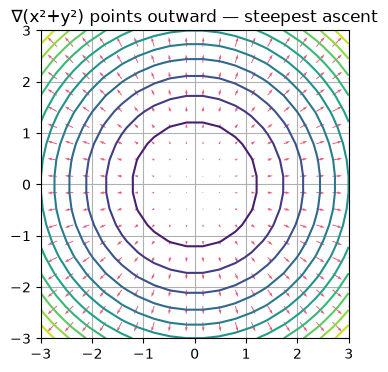

In [4]:
gx = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(gx, gx); Z = X**2 + Y**2
U, V = 2*X, 2*Y                       # gradient = (∂f/∂x, ∂f/∂y)
plt.contour(X, Y, Z, levels=12, cmap='viridis')
plt.quiver(X, Y, U, V, color='crimson', alpha=0.7)
plt.title("∇(x²+y²) points outward — steepest ascent")
plt.gca().set_aspect('equal'); plt.show()

## 6. Gradient descent and the cost function

Predict house price from size: roughly $\text{price} = 1600\times\text{size} + 20000$. In general a linear model is $\hat{y} = wx + b$ — $w$ the **weight**, $b$ the **bias**. We don't know the best $w,b$; we **learn** them from data.

**Cost function (MSE).** The error per point is actual − predicted; we square it (so signs don't cancel, and it stays smooth/differentiable) and average:
$$J(w,b) = \frac{1}{n}\sum_i \big(y_i - (w x_i + b)\big)^2.$$
Think of $J$ as a **landscape** over $(w,b)$; the lowest point is the best fit.

**Update rule.** Feel the slope, step downhill, repeat:
$$w \leftarrow w - \alpha\,\frac{\partial J}{\partial w}, \qquad b \leftarrow b - \alpha\,\frac{\partial J}{\partial b}.$$
The partials come from the **chain rule** peeling the square. Let's start with the simplest case, $J(w)=w^2$.

In [ ]:
w, lr = 3.0, 0.1
hist = [w]
for _ in range(25):
    grad = 2*w                 # dJ/dw
    w = w - lr*grad            # step opposite the slope
    hist.append(w)
print("final w ≈", round(w, 4), "(true minimum is 0)")

ws = np.linspace(-3.5, 3.5, 200)
h = np.array(hist)
plt.plot(ws, ws**2, label="J(w) = w²")
plt.plot(h, h**2, 'o-', color='crimson', ms=4, label="descent steps")
plt.xlabel("w"); plt.ylabel("J(w)"); plt.title("Rolling down to the minimum")
plt.legend(); plt.show()

Now the **full model** on three matatu rides — distance $x$, fare $y$: $(1,2),(2,4),(3,5)$. Starting from a flat line ($w=b=0$), watch the loss fall and the line tilt toward the data. Each step uses
$$\frac{\partial J}{\partial w} = -\frac{2}{n}\sum_i (y_i-\hat y_i)x_i, \qquad \frac{\partial J}{\partial b} = -\frac{2}{n}\sum_i (y_i-\hat y_i).$$

In [ ]:
x = np.array([1., 2., 3.]); y = np.array([2., 4., 5.]); n = len(x)
w, b, lr = 0.0, 0.0, 0.1
losses = []
for step in range(60):
    y_pred = w*x + b
    error  = y - y_pred
    losses.append(np.mean(error**2))
    dw = -(2/n)*np.sum(error*x)      # ∂J/∂w  (chain rule)
    db = -(2/n)*np.sum(error)        # ∂J/∂b
    w -= lr*dw; b -= lr*db
print(f"learned line:  y ≈ {w:.2f}·x + {b:.2f}")
print(f"loss: {losses[0]:.2f}  ->  {losses[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(x, y, color='navy', label="data")
xx = np.linspace(0.5, 3.5, 50)
ax[0].plot(xx, w*xx + b, color='crimson', label="fitted line")
ax[0].set_title("Linear regression fit"); ax[0].legend()
ax[1].plot(losses, color='seagreen'); ax[1].set_title("Loss falling each step")
ax[1].set_xlabel("step"); ax[1].set_ylabel("MSE")
plt.show()

**Why calculus?** Without it you'd step *randomly*. The derivative tells you which way is downhill, so every step reduces error. Every model that learns runs on this.

## 7. Neural networks and backpropagation

A **neuron** is a tiny calculator: multiply each input by a **weight**, add a **bias**, pass through an **activation** that decides how strongly it fires. A **network** stacks neurons in layers; all its knowledge lives in the weights (random at first → it knows nothing). Learning = adjusting weights:

1. **Forward pass** — feed input, get an output (maybe wrong).
2. **Measure error** — compare to the truth.
3. **Backward pass (backprop)** — how much did each weight contribute to the error? That is a partial derivative $\frac{\partial \text{Error}}{\partial w}$.
4. **Update** — nudge each weight downhill; repeat.

A weight in an early layer affects the error through a long chain, so we use the **chain rule** to multiply the little effects. **Backpropagation = the chain rule applied efficiently to every weight.** Here is one neuron, one gradient step, fully by hand.

In [ ]:
import math
# one neuron:  x --> z = w*x + b --> a = sigmoid(z) --> loss = (a - y)²
x_in, y_true = 1.5, 0.0
w, b = 0.8, 0.1
sigmoid = lambda z: 1 / (1 + math.exp(-z))

z = w*x_in + b
a = sigmoid(z)
loss = (a - y_true)**2

# backprop = chain rule:  dL/dw = dL/da * da/dz * dz/dw
dL_da = 2*(a - y_true)
da_dz = a*(1 - a)
dz_dw = x_in
dL_dw = dL_da * da_dz * dz_dw

print(f"prediction a = {a:.3f},  loss = {loss:.3f}")
print(f"dL/dw (chain rule) = {dL_dw:.4f}")
print(f"updated w: {w:.3f} -> {w - 0.5*dL_dw:.3f}")

**The dial analogy:** thousands of dials (weights); backprop is a smart meter on each one saying *turn this clockwise to reduce error, that one counter-clockwise, this one barely matters* — exactly what the partial derivatives give you.

## 8. Convolutional neural networks (CNNs)

A 100×100 image has 10,000 pixels; connecting every pixel to every neuron means *millions* of weights — expensive and blind to the fact that nearby pixels relate. CNNs slide small **filters (kernels)** over the image instead.

**Convolution:** place the filter at a spot, multiply each filter number by the pixel under it, add them up (one output number), slide one step, repeat. The result is a **feature map** that lights up where the filter's pattern appears. Below, a vertical-edge filter $\begin{bmatrix}1&0&-1\\1&0&-1\\1&0&-1\end{bmatrix}$ finds the edge between dark and bright.

In [ ]:
img = np.zeros((9, 9)); img[:, 5:] = 1.0          # left dark, right bright
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])                      # vertical-edge detector

def convolve2d(image, k):
    kh, kw = k.shape; H, W = image.shape
    out = np.zeros((H - kh + 1, W - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(image[i:i+kh, j:j+kw] * k)
    return out

feat = convolve2d(img, kernel)
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img, cmap='gray');  ax[0].set_title("input image")
ax[1].imshow(feat, cmap='gray'); ax[1].set_title("feature map (edge lights up)")
for a in ax: a.axis('off')
plt.show()

**Where's the calculus?** Filters start random; the network learns useful ones via **backprop**, computing $\frac{\partial \text{Error}}{\partial(\text{filter value})}$ for each number. And convolution itself is, in continuous form, an **integral**: $(f*g)(t) = \int f(\tau)\,g(t-\tau)\,d\tau$ — "accumulate contributions as you slide," straight from Section 3.

## 9. Regularisation — Ridge and Lasso

Give a model 10 points and it can fit a tidy line — or a wild curve through every point. The wild curve has zero training error but is hopeless on new data: **overfitting** (it memorised noise). It happens when a model is *too complex* — too many weights free to wiggle.

**Fix:** add a penalty for complexity — a tax on large weights:
$$\text{Ridge (L2):}\;\; J_{\text{new}} = J + \lambda\sum w^2, \qquad \text{Lasso (L1):}\;\; J_{\text{new}} = J + \lambda\sum |w|.$$
$\lambda$ controls how much we punish size. Differentiating Ridge adds a $2\lambda w$ term to the update that shrinks weights each step (**weight decay**). Below: a degree-9 fit overfits 10 noisy points; Ridge (L2) keeps the weights small and the curve sane.

In [ ]:
rng = np.random.default_rng(0)
xs = np.linspace(0, 1, 10)
ys = np.sin(2*np.pi*xs) + rng.normal(0, 0.15, size=xs.shape)

def poly_features(v, degree):
    return np.vstack([v**p for p in range(degree + 1)]).T

deg = 9
P = poly_features(xs, deg)
w_ols   = np.linalg.lstsq(P, ys, rcond=None)[0]          # plain least squares
lam = 1e-2
w_ridge = np.linalg.solve(P.T @ P + lam*np.eye(deg+1), P.T @ ys)  # (PᵀP+λI)⁻¹Pᵀy

grid = np.linspace(0, 1, 200); G = poly_features(grid, deg)
plt.scatter(xs, ys, color='navy', zorder=3, label="noisy data")
plt.plot(grid, G @ w_ols,   color='crimson', label="degree-9 (overfit)")
plt.plot(grid, G @ w_ridge, color='seagreen', lw=2, label="ridge / L2")
plt.ylim(-1.8, 1.8); plt.title("Regularisation tames overfitting"); plt.legend(); plt.show()

print("max |weight|  OLS  :", round(np.abs(w_ols).max(), 1))
print("max |weight|  Ridge:", round(np.abs(w_ridge).max(), 1), " (much smaller)")

**Lasso's extra trick:** because of the $|w|$ shape, it can push some weights all the way to **zero**, dropping irrelevant features — that's feature selection. Either way, calculus (differentiating the penalised cost) guides the optimisation.

## 10. Support vector machines (SVM)

Two classes of points; many lines separate them — which is **best**? SVM picks the line **farthest from the nearest points** of each class. That gap is the **margin**, and SVM *maximises* it (most robust to new, scattered points). In 2D it's a line; higher up, a **hyperplane**.

The math: maximise $\frac{2}{\lVert w\rVert}$ subject to $y_i(w\cdot x_i + b) \ge 1$, which is the same as **minimising** $\tfrac12\lVert w\rVert^2$ (easier to differentiate). That's a **constrained optimisation** solved with **Lagrange multipliers** — partial derivatives set to zero. The nearest points that pin the boundary are the **support vectors**. The plot below is illustrative: a separating line and its margin.

In [ ]:
rng = np.random.default_rng(1)
A = rng.normal([2, 2], 0.5, size=(15, 2))     # class +1
B = rng.normal([5, 5], 0.5, size=(15, 2))     # class -1
plt.scatter(A[:, 0], A[:, 1], color='crimson', label="class +1")
plt.scatter(B[:, 0], B[:, 1], color='navy',    label="class -1")
xx = np.linspace(0.5, 6.5, 50)
plt.plot(xx, -xx + 7, 'k-',  label="decision boundary")
plt.plot(xx, -xx + 8, 'k--', alpha=0.5)
plt.plot(xx, -xx + 6, 'k--', alpha=0.5, label="margin")
plt.title("SVM: the boundary with the widest margin")
plt.gca().set_aspect('equal'); plt.legend(); plt.show()

## The whole arc — connecting everything

The entire story of *how a model learns* is calculus from start to finish:

| Concept | Simple explanation | Why calculus? |
|---|---|---|
| **Derivative** | How fast something changes (slope) | Sensitivity of the cost to a parameter |
| **Integral** | A continuous sum (area under a curve) | Probabilities, expectations, convolution |
| **Partial derivative** | Effect of one dial, others fixed | How error changes when we adjust one weight |
| **Gradient** | All partials at once (points uphill) | Tells us which way is downhill |
| **Gradient descent** | Walk downhill to the minimum | Uses the gradient to choose each step |
| **Cost function** | How wrong predictions are | We differentiate it to find its minimum |
| **Backpropagation** | Every weight's effect, efficiently | The chain rule across the network |
| **Convolution (CNN)** | Slide a filter to extract features | The discrete form of an integral |
| **Regularisation** | A penalty that keeps models simple | We differentiate the penalised cost |
| **SVM** | The widest-margin boundary | Constrained optimisation via derivatives |

**A model learns by minimising a cost.** Minimising → find where the slope is zero (*derivatives*). Getting there → follow the downhill *gradient*. Through many layers → the *chain rule* (backprop). The probability machinery underneath → *integrals*. Calculus isn't a hurdle before the real material; it **is** the mechanism of learning.

*Teach the questions first — "how fast?" and "how much?" — and every algorithm here becomes a careful answer to those two questions.*